<a href="https://colab.research.google.com/github/abdelrahman-rajab-hassan/unsupervised-ml-lab/blob/main/minor-projects/customer-segmentation-using-kmeans/customer_segmentation_using_KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exercise Original Name: KMeans_Clustering_(Core).ipynb

Exercise Modified Name: customer_segmentation_using_KMeans.ipynb

In [ ]:
# import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# import machine learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn import set_config

set_config(transform_output = 'pandas')

import missingno as msno
import my_utils as mu


# Exploratory Data Analysis **`(EDA)`** for the dataset

In [ ]:
df = pd.read_csv('cust_seg.csv')
df.head()

,Unnamed: 0,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,0,1,41,2,6,19,0.124,1.073,0.0,6.3
1,1,2,47,1,26,100,4.582,8.218,0.0,12.8
2,2,3,33,2,10,57,6.111,5.802,1.0,20.9
3,3,4,29,2,4,19,0.681,0.516,0.0,6.3
4,4,5,47,1,31,253,9.308,8.908,0.0,7.2


In [ ]:
# check for df info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       850 non-null    int64  
 1   Customer Id      850 non-null    int64  
 2   Age              850 non-null    int64  
 3   Edu              850 non-null    int64  
 4   Years Employed   850 non-null    int64  
 5   Income           850 non-null    int64  
 6   Card Debt        850 non-null    float64
 7   Other Debt       850 non-null    float64
 8   Defaulted        700 non-null    float64
 9   DebtIncomeRatio  850 non-null    float64
dtypes: float64(4), int64(6)
memory usage: 66.5 KB


In [ ]:
# check for duplaicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# check for missing values
df.isna().sum()

Unnamed: 0           0
Customer Id          0
Age                  0
Edu                  0
Years Employed       0
Income               0
Card Debt            0
Other Debt           0
Defaulted          150
DebtIncomeRatio      0
dtype: int64

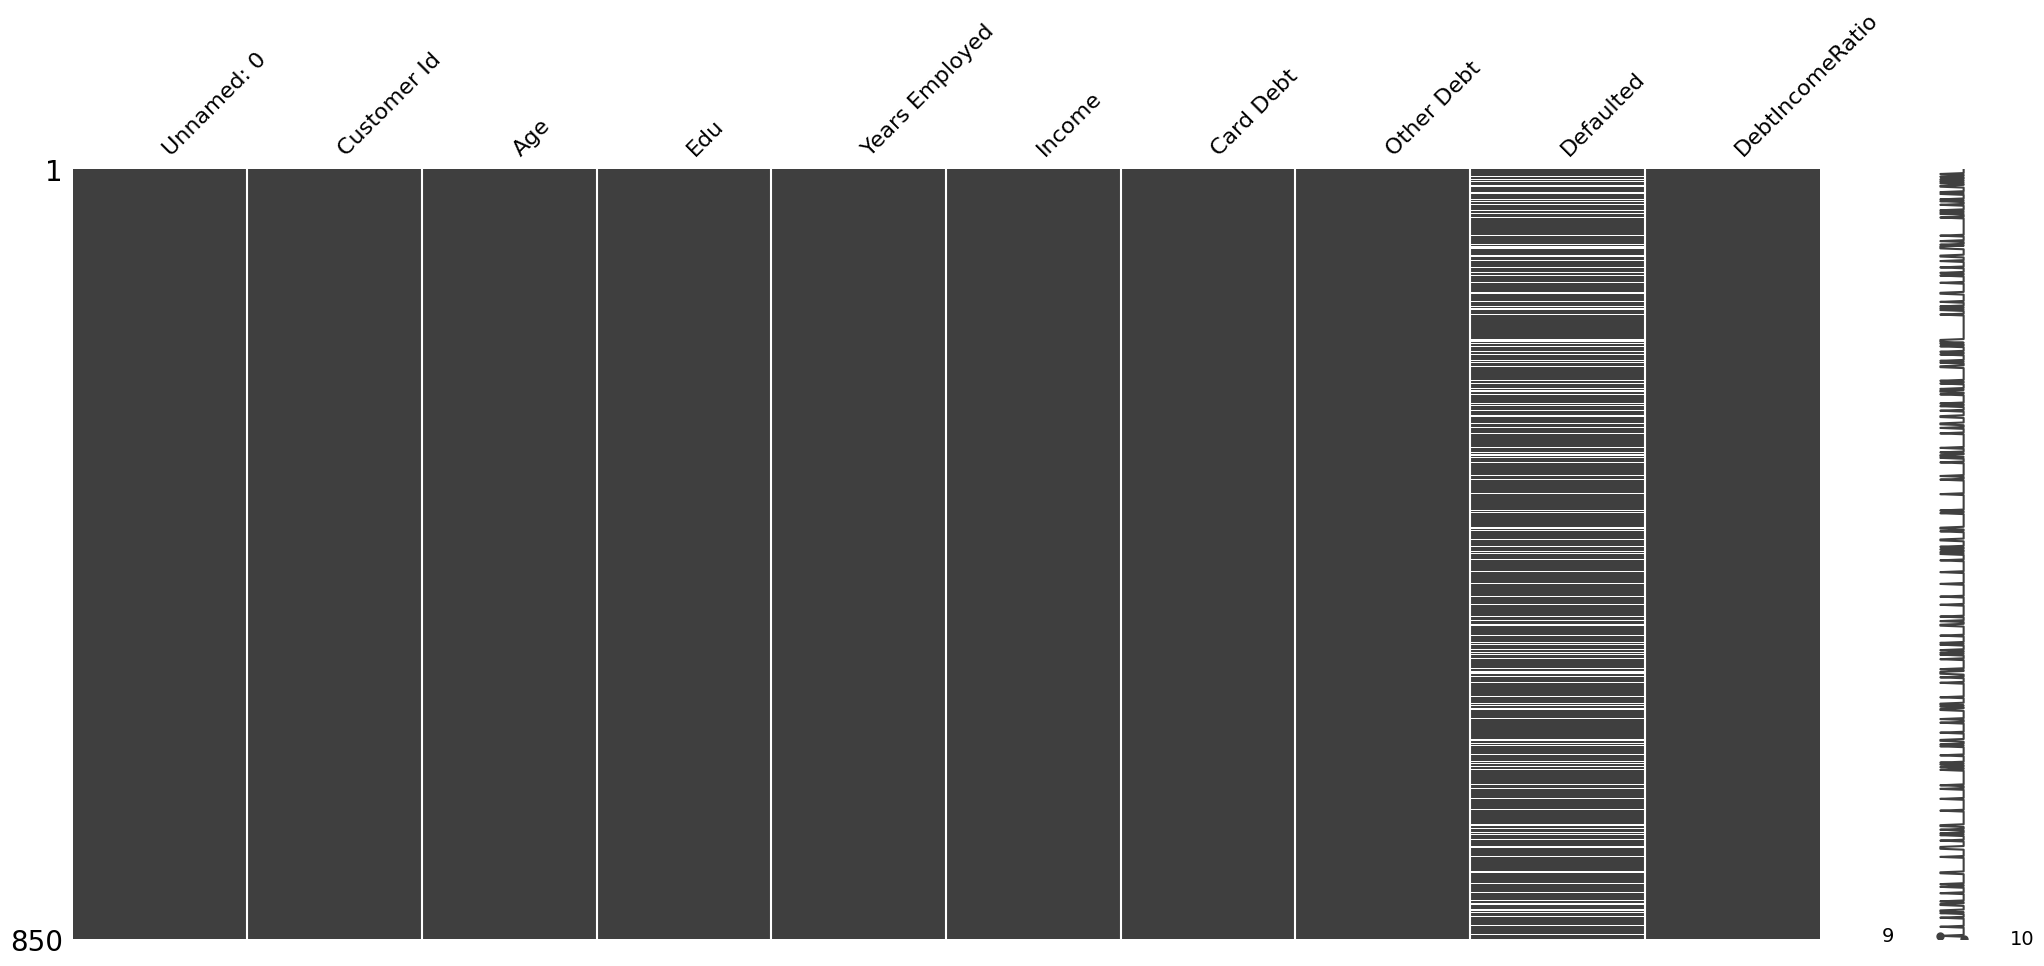

In [ ]:
# use a visual representation for missing values
msno.matrix(df);

In [ ]:
# drop unnecessary columns
df = df.drop(columns = ['Unnamed: 0', 'Customer Id'])
df.columns

Index(['Age', 'Edu', 'Years Employed', 'Income', 'Card Debt', 'Other Debt',
       'Defaulted', 'DebtIncomeRatio'],
      dtype='str')

> ### The `Defaulted` column contains missing values; I will either drop the affected rows or exclude it as a feature from my KMeans analysis.

In [ ]:
# check the defaulted missing values sum
df['Defaulted'].isna().sum()

np.int64(150)

In [ ]:
# drop rows where 'Defaulted' is missing
df = df.dropna(subset=['Defaulted'])

# re-check null values
df['Defaulted'].isna().sum()

np.int64(0)

In [ ]:
# re-check null values in the entrie df
df.isna().sum().sum()

np.int64(0)

# Apply Preprocessing Steps

In [ ]:
# scale the features for KMeans clustering
scale = StandardScaler()

# scaler the df
scaled_df = scale.fit_transform(df)

# check the scaled df
scaled_df.head()


,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,0.768304,0.298793,-0.359007,-0.723102,-0.675699,-0.604284,-0.594950,-0.580528
1,1.519090,-0.779325,2.647029,1.478707,1.431421,1.570620,-0.594950,0.372222
2,-0.232744,0.298793,0.242201,0.309845,2.154119,0.835201,1.680814,1.559495
3,-0.733267,0.298793,-0.659610,-0.723102,-0.412427,-0.773833,-0.594950,-0.580528
4,1.519090,-0.779325,3.398538,5.637681,3.665215,1.780653,-0.594950,-0.448609


# Apply **`KMeans`** Clustering to the Preprocessed Dataset

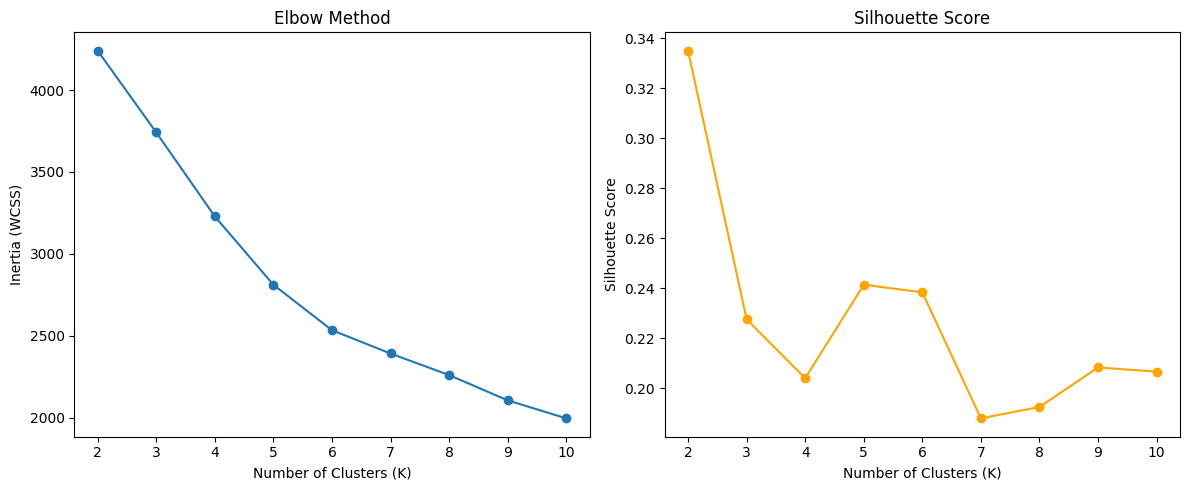

In [ ]:
# plot the two main metrics for the KMeans
mu.plot_optimal_k(scaled_df)

> The Silhouette Score peaks at **K=2** (~0.335), making it the statistically optimal choice.
The Elbow plot shows no clear inflection point, with inertia declining gradually throughout.
From a business standpoint, **K=2** also aligns naturally with the binary nature of the `Defaulted` outcome.
Therefore, **K=2** is selected as the optimal number of clusters.

In [ ]:
# instantiate the KMeans clustering with 2 clusters
kmeans = KMeans(n_clusters = 2, n_init = 'auto', random_state = 43)

# fit the model
kmeans.fit(scaled_df)

# add cluster column to the table
df['cluster'] = kmeans.labels_

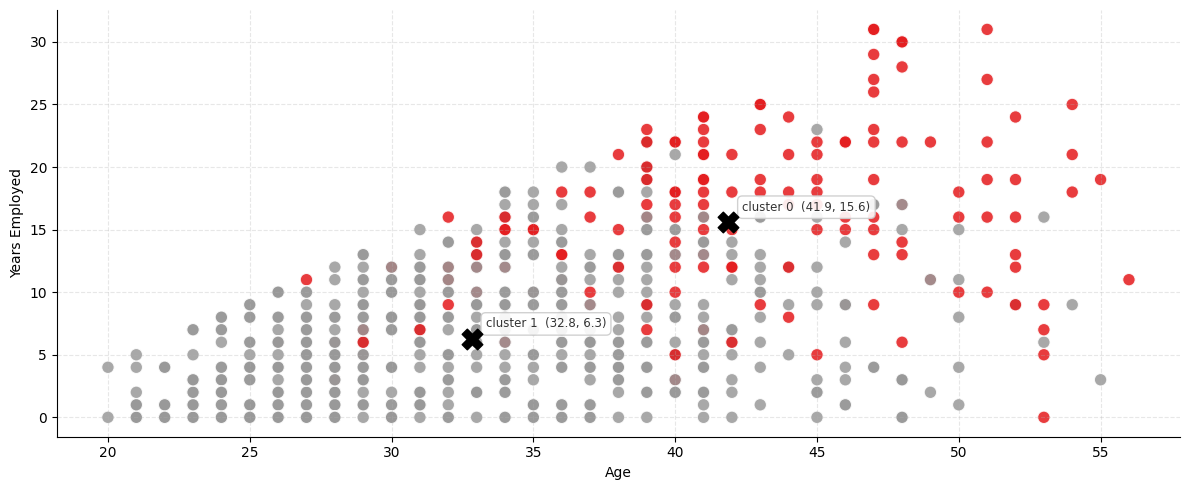

In [ ]:
# for demonstration purposes, this line shows how the two clusters are separeted
mu.plot_clusters(df, 'Age', 'Years Employed', kmeans, scale, color = 'Set1')

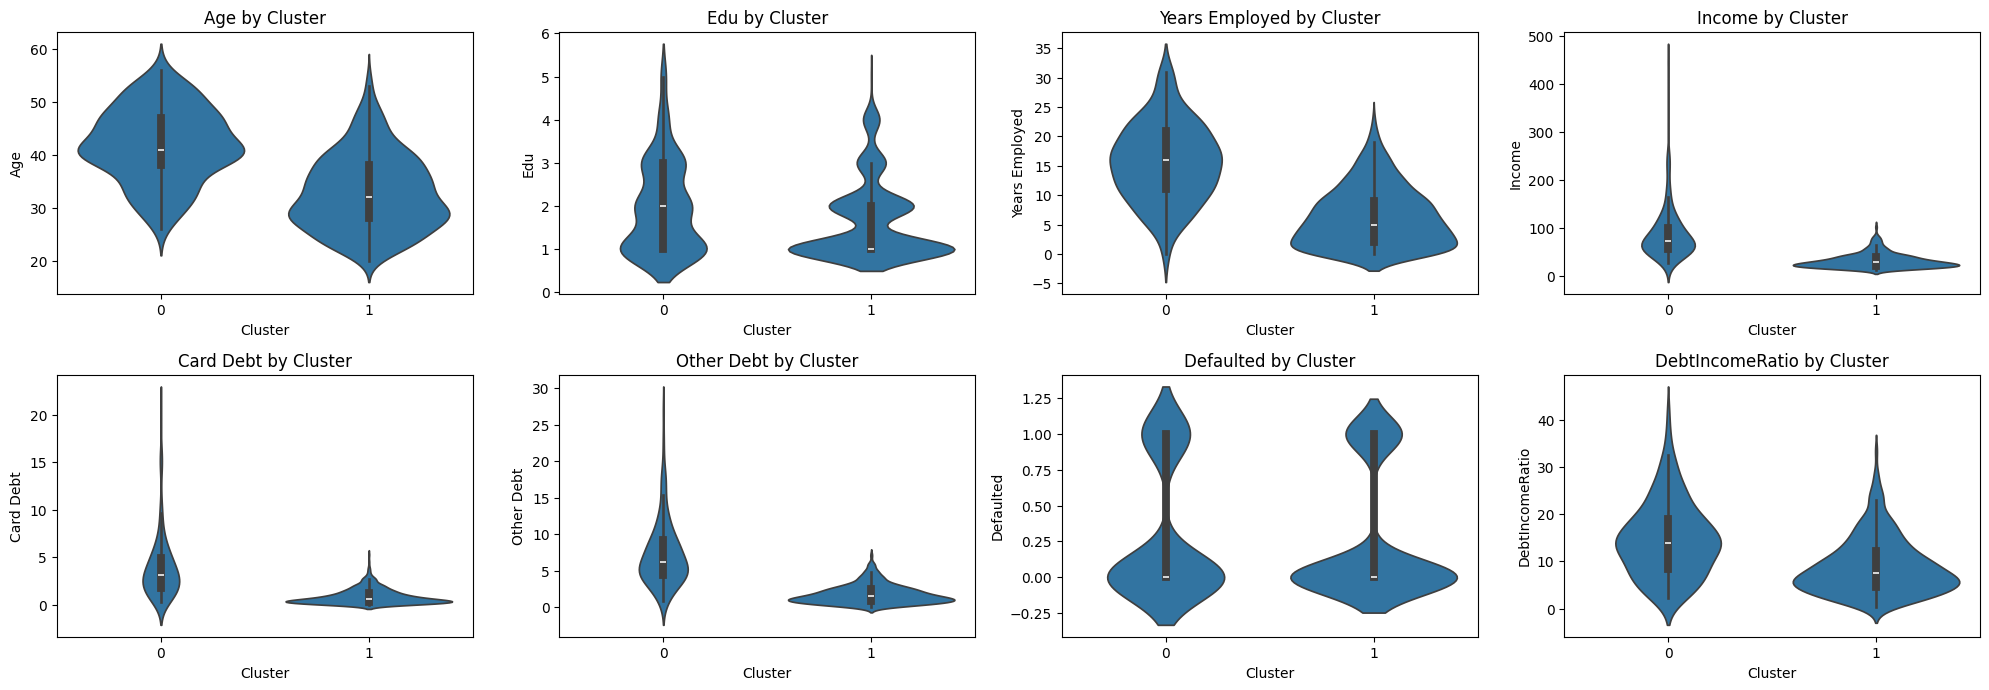

In [ ]:
# Visualize the distribution of each feature per cluster
feature_cols = [col for col in df.columns if col != 'cluster']

fig, axes = plt.subplots(3, 4, figsize=(20, 10))
axes = axes.ravel()

for i, col in enumerate(feature_cols):

    sns.violinplot(data=df, x='cluster', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(col)

for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Cluster Analysis — Key Insights

### Age by Cluster
- **Cluster 0** represents a **middle-aged** group, with the majority of customers falling between **35 and 50** years old, with some reaching up to ~60.
- **Cluster 1** represents a **younger** group, tightly concentrated between **20 and 35** years old.

> **In plain terms:** Cluster 0 is a middle-aged group, while Cluster 1 is a younger group.

### Education by Cluster
- **Cluster 0** has a **diverse** range of education levels (0–3), indicating varied academic backgrounds.
- **Cluster 1** is more **homogeneous**, with most customers sharing a similar, relatively low education level (1–2).

> **In plain terms:** Cluster 0 customers come from varied educational backgrounds, while Cluster 1 customers largely share the same education level.

### Years Employed by Cluster
- **Cluster 0** customers are **experienced professionals**, with years employed reaching up to ~30 years — consistent with their older age.
- **Cluster 1** customers are **early in their careers**, with most having fewer than 5 years of employment experience.

> **In plain terms:** Cluster 0 is a seasoned workforce, while Cluster 1 is just getting started in their careers.

### Income by Cluster
- **Cluster 0** earns significantly more on average, with a wide income distribution and notable outliers reaching up to **~500K** — likely senior professionals or executives.
- **Cluster 1** barely reaches an income of **~100K**, with no outliers, indicating a very homogeneous low-income group.

> **In plain terms:** Cluster 0 represents financially established customers with high and varied incomes, while Cluster 1 represents low-income customers with little financial variation.

### Card Debt by Cluster
- **Cluster 0** has a wider distribution with a longer tail reaching up to **~20**, indicating varied and significantly higher credit card debt among some customers.
- **Cluster 1** is tightly concentrated near **0–1**, indicating consistently low card debt across almost all customers.

> **In plain terms:** Cluster 0 customers are active credit card users who carry substantial debt, while Cluster 1 customers barely use credit at all — likely constrained by their low income.

### Other Debt by Cluster
- **Cluster 0** shows a wider distribution reaching up to **~30**, indicating higher and more varied non-credit-card debt (loans, mortgages, etc.).
- **Cluster 1** is again tightly concentrated near **0–1**, indicating virtually no other debt obligations.

> **In plain terms:** Cluster 0 carries significantly more debt across all debt types, while Cluster 1 is virtually debt-free — whether by choice or financial necessity.

### Debt-to-Income Ratio by Cluster
- **Cluster 0** has a wider distribution reaching up to **~40**, meaning a portion of customers are spending a significant share of their income on debt repayment.
- **Cluster 1** is tightly concentrated near **0–10**, indicating that their debt burden is very manageable relative to their income.

> **In plain terms:** Despite earning more, Cluster 0 is financially stretched due to their aggressive borrowing, while Cluster 1 lives well within their means.

---

### Overall Pattern
Across all features analyzed, a **consistent story** emerges:
> **Cluster 0** → Older, more experienced, higher-income customers who are active borrowers with higher debt levels and a slightly higher default rate.
> **Cluster 1** → Younger, early-career, lower-income customers who carry little to no debt and are financially conservative.

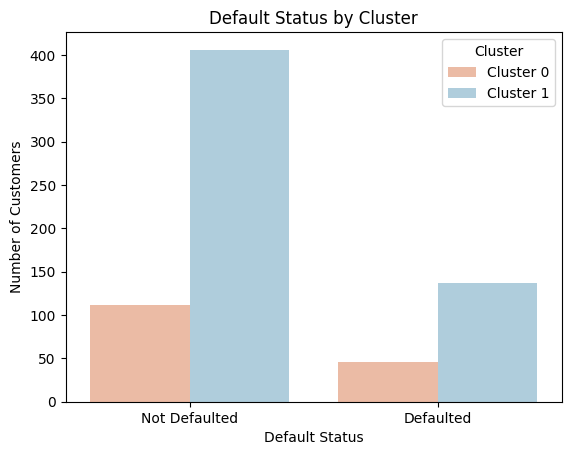

In [ ]:
# Map 0/1 to meaningful labels for readability
df['Defaulted'] = df['Defaulted'].map({0.0: 'Not Defaulted', 1.0: 'Defaulted'})

sns.countplot(data=df, x='Defaulted', hue='cluster', palette='RdBu')
plt.title('Default Status by Cluster')
plt.xlabel('Default Status')
plt.ylabel('Number of Customers')
plt.legend(title='Cluster', labels=['Cluster 0', 'Cluster 1'])
plt.show()

### Default Status by Cluster
- **Cluster 0** has approximately **115 non-defaulted** and **50 defaulted** customers,
yielding a default rate of **~30%**.
- **Cluster 1** has approximately **405 non-defaulted** and **135 defaulted** customers,
yielding a default rate of **~25%**.

> **In plain terms:** Despite being the wealthier group, Cluster 0 defaults at a
higher rate than Cluster 1 — their aggressive borrowing behavior increases their
financial risk regardless of their higher income level.

> **Key Insight:** High income does not guarantee low risk. Cluster 0's higher
debt obligations stretch their finances, making them a riskier group than their
income alone would suggest. This should be a critical consideration when designing
credit card offerings for each segment.

---

## Stakeholder Recommendations

### Recommendation 1 — Premium Credit Cards for Cluster 0
Market **high-limit, rewards-based credit cards** to Cluster 0. These are
financially established customers with high incomes and a demonstrated history
of active credit usage. However, given their **~30% default rate**, it is
advisable to enforce **stricter credit assessments** and set **responsible credit
limits** to mitigate risk.

### Recommendation 2 — Starter Credit Cards for Cluster 1
Market **secured or low-limit starter credit cards** to Cluster 1. These are
young, low-income customers who are early in their careers and currently
carry little to no debt. Introducing them to credit responsibly now builds
**long-term customer loyalty** as their income and spending power grow over time.

---

> **Bottom Line:** The two clusters represent fundamentally different customer
profiles — **established but risky borrowers** vs. **conservative but
low-spending beginners**. A one-size-fits-all credit card strategy would
fail both groups. Tailoring the product offering to each segment maximizes
revenue while managing default risk effectively.